# Slopless Star History

This notebook reads `slopless-stars.csv`, builds a minute-level time series, and plots cumulative stars plus per-minute changes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_path = Path("slopless-stars.csv")
if not csv_path.exists():
    csv_path = Path("analytics/star-history/slopless-stars.csv")
output_dir = csv_path.parent
stars = pd.read_csv(csv_path, parse_dates=["starred_at"])
stars = stars.sort_values("starred_at").reset_index(drop=True)
stars["star_number"] = range(1, len(stars) + 1)
stars["minute"] = stars["starred_at"].dt.floor("min")
stars["previous_starred_at"] = stars["starred_at"].shift(1)
stars["seconds_since_previous"] = (stars["starred_at"] - stars["previous_starred_at"]).dt.total_seconds()
stars.head()

,starred_at,user,user_url,star_number,minute,previous_starred_at,seconds_since_previous
0,2026-05-17 20:52:44+00:00,Davidfrosted,https://github.com/Davidfrosted,1,2026-05-17 20:52:00+00:00,NaT,NaN
1,2026-05-17 20:52:46+00:00,Wereca,https://github.com/Wereca,2,2026-05-17 20:52:00+00:00,2026-05-17 20:52:44+00:00,2.0
2,2026-05-17 20:53:47+00:00,dasko2026,https://github.com/dasko2026,3,2026-05-17 20:53:00+00:00,2026-05-17 20:52:46+00:00,61.0
3,2026-05-17 20:53:59+00:00,mdsajibmolla666-gif,https://github.com/mdsajibmolla666-gif,4,2026-05-17 20:53:00+00:00,2026-05-17 20:53:47+00:00,12.0
4,2026-05-17 20:54:31+00:00,Ahmedcu1,https://github.com/Ahmedcu1,5,2026-05-17 20:54:00+00:00,2026-05-17 20:53:59+00:00,32.0


In [2]:
summary = {
    "stars": len(stars),
    "first_star": stars["starred_at"].min(),
    "last_star": stars["starred_at"].max(),
    "active_minutes": stars["minute"].nunique(),
    "max_stars_in_one_minute": stars.groupby("minute").size().max(),
}
summary

{'stars': 255,
 'first_star': Timestamp('2026-05-17 20:52:44+0000', tz='UTC'),
 'last_star': Timestamp('2026-05-21 08:06:22+0000', tz='UTC'),
 'active_minutes': 229,
 'max_stars_in_one_minute': np.int64(3)}

In [3]:
minute_counts = stars.set_index("starred_at").resample("min").size().rename("stars_added")
minute_curve = minute_counts.to_frame()
minute_curve["cumulative_stars"] = minute_curve["stars_added"].cumsum()
minute_curve["stars_added_5min"] = minute_curve["stars_added"].rolling(5, min_periods=1).sum()
minute_curve["stars_added_15min"] = minute_curve["stars_added"].rolling(15, min_periods=1).sum()
minute_curve.tail()

,stars_added,cumulative_stars,stars_added_5min,stars_added_15min
starred_at,,,,
2026-05-21 08:02:00+00:00,0,254,0.0,1.0
2026-05-21 08:03:00+00:00,0,254,0.0,1.0
2026-05-21 08:04:00+00:00,0,254,0.0,1.0
2026-05-21 08:05:00+00:00,0,254,0.0,0.0
2026-05-21 08:06:00+00:00,1,255,1.0,1.0


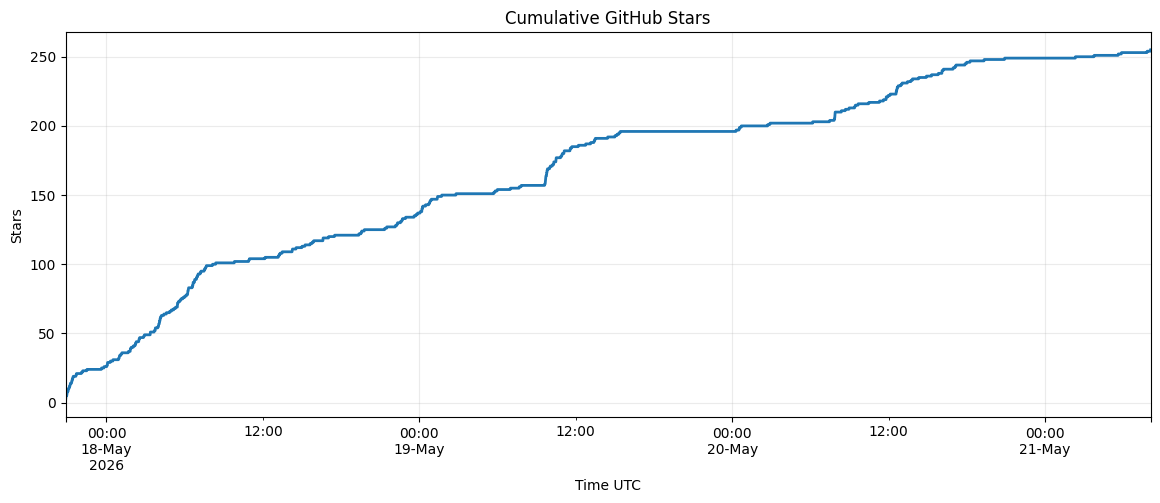

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
minute_curve["cumulative_stars"].plot(ax=ax, linewidth=2)
ax.set_title("Cumulative GitHub Stars")
ax.set_xlabel("Time UTC")
ax.set_ylabel("Stars")
ax.grid(True, alpha=0.25)
plt.show()

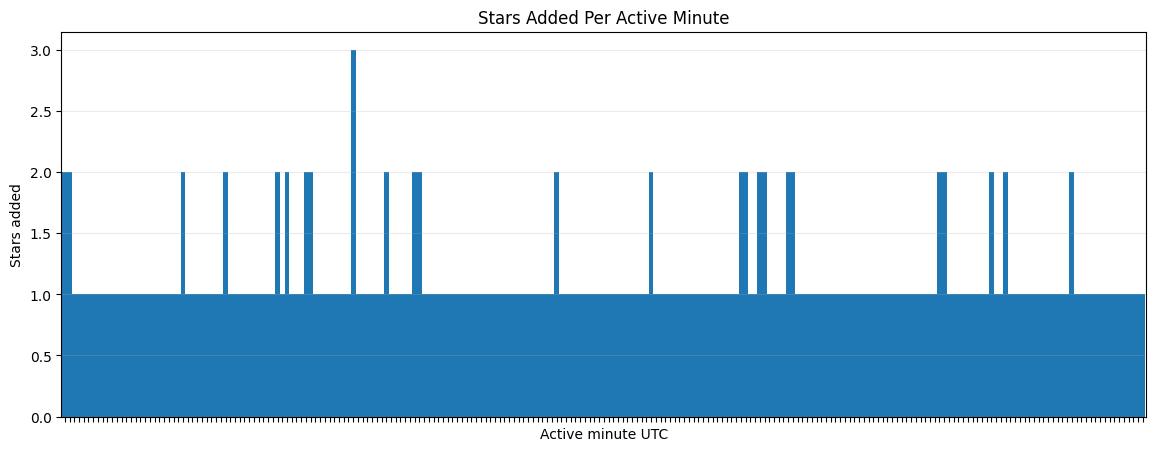

,stars_added,cumulative_stars,stars_added_5min,stars_added_15min
starred_at,,,,
2026-05-18 05:27:00+00:00,3,72,3.0,4.0
2026-05-17 20:52:00+00:00,2,2,2.0,2.0
2026-05-19 09:41:00+00:00,2,162,5.0,5.0
2026-05-19 10:19:00+00:00,2,174,2.0,3.0
2026-05-20 07:53:00+00:00,2,208,4.0,4.0
2026-05-18 03:45:00+00:00,2,54,2.0,3.0
2026-05-20 07:54:00+00:00,2,210,6.0,6.0
2026-05-18 00:05:00+00:00,2,29,3.0,3.0
2026-05-19 09:40:00+00:00,2,160,3.0,3.0


In [5]:
active_minutes = minute_curve[minute_curve["stars_added"] > 0]

fig, ax = plt.subplots(figsize=(14, 5))
active_minutes["stars_added"].plot(ax=ax, kind="bar", width=1)
ax.set_title("Stars Added Per Active Minute")
ax.set_xlabel("Active minute UTC")
ax.set_ylabel("Stars added")
ax.tick_params(axis="x", labelbottom=False)
ax.grid(True, axis="y", alpha=0.25)
plt.show()

active_minutes.sort_values("stars_added", ascending=False).head(20)

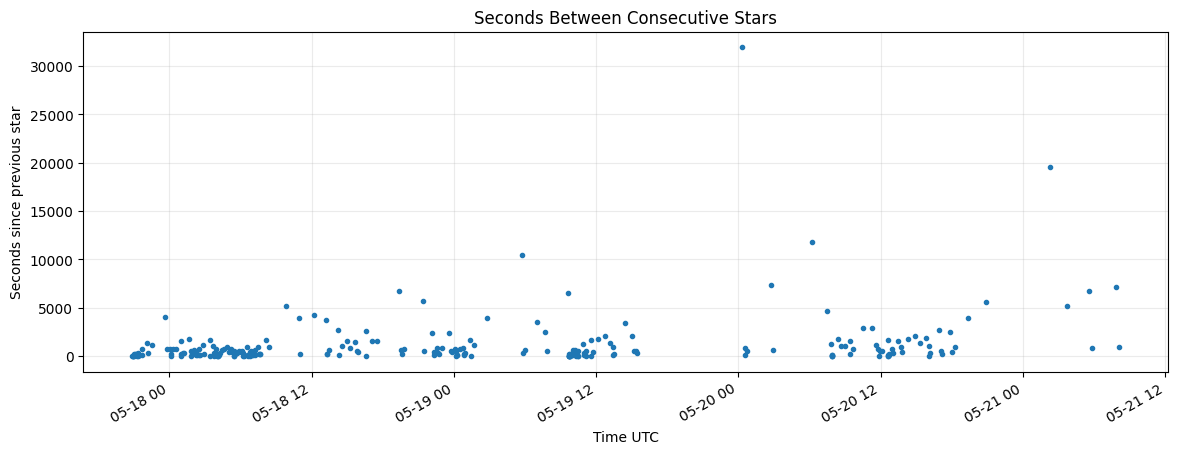

,starred_at,user,seconds_since_previous
225,2026-05-20 12:37:59+00:00,olegkononov423-collab,133.0
226,2026-05-20 12:39:00+00:00,manha9330,61.0
227,2026-05-20 12:40:51+00:00,Vaaddii,111.0
228,2026-05-20 12:44:54+00:00,hananansari123g-ops,243.0
229,2026-05-20 12:57:25+00:00,shoaib44-24,751.0
230,2026-05-20 13:02:28+00:00,kamalislam8811,303.0
231,2026-05-20 13:27:54+00:00,fatematujj774-sketch,1526.0
232,2026-05-20 13:43:35+00:00,frontalex,941.0
233,2026-05-20 13:50:06+00:00,nadianeha333,391.0
234,2026-05-20 14:19:37+00:00,arifulislam22001122-blip,1771.0


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
stars.plot(x="starred_at", y="seconds_since_previous", ax=ax, style=".", legend=False)
ax.set_title("Seconds Between Consecutive Stars")
ax.set_xlabel("Time UTC")
ax.set_ylabel("Seconds since previous star")
ax.grid(True, alpha=0.25)
plt.show()

stars[["starred_at", "user", "seconds_since_previous"]].tail(30)

## Account quality and campaign-window analysis

This section joins public GitHub profile metadata and compares three survivor buckets: the first 100 stars, the next 58 stars, and the remaining stars. These buckets match the stated campaign sequence, but they are survivor buckets, not historical totals for removed or banned accounts.

In [7]:
profiles_path = output_dir / "slopless-stargazer-profiles.csv"
profiles = pd.read_csv(profiles_path, parse_dates=["created_at", "updated_at"])
profiles = profiles.rename(columns={"user": "profile_user"})
star_profiles = stars.merge(profiles, left_on="user", right_on="profile_user", how="left")
star_profiles["account_age_days_at_star"] = (star_profiles["starred_at"] - star_profiles["created_at"]).dt.total_seconds() / 86400
profile_fields = ["company", "blog", "location", "bio", "twitter_username"]
star_profiles["has_profile_detail"] = star_profiles[profile_fields].fillna("").ne("").any(axis=1)
star_profiles["low_signal"] = (
    star_profiles["followers"].fillna(0).eq(0)
    & star_profiles["public_repos"].fillna(0).eq(0)
    & ~star_profiles["has_profile_detail"]
)
star_profiles["very_new"] = star_profiles["account_age_days_at_star"] < 30
star_profiles["survivor_bucket"] = pd.cut(
    star_profiles["star_number"],
    bins=[0, 100, 158, len(star_profiles)],
    labels=["first_100_survivors", "middle_58_survivors", f"last_{len(star_profiles) - 158}_survivors"],
)
star_profiles[["star_number", "starred_at", "user", "survivor_bucket", "account_age_days_at_star", "followers", "public_repos", "low_signal", "very_new"]].head()

,star_number,starred_at,user,survivor_bucket,account_age_days_at_star,followers,public_repos,low_signal,very_new
0,1,2026-05-17 20:52:44+00:00,Davidfrosted,first_100_survivors,37.082211,1,2,False,False
1,2,2026-05-17 20:52:46+00:00,Wereca,first_100_survivors,392.895035,3,1,False,False
2,3,2026-05-17 20:53:47+00:00,dasko2026,first_100_survivors,28.587002,0,2,False,True
3,4,2026-05-17 20:53:59+00:00,mdsajibmolla666-gif,first_100_survivors,52.663160,0,4,False,False
4,5,2026-05-17 20:54:31+00:00,Ahmedcu1,first_100_survivors,84.226852,2,8,False,False


In [8]:
bucket_summary = star_profiles.groupby("survivor_bucket", observed=True).agg(
    stars=("user", "count"),
    start=("starred_at", "min"),
    end=("starred_at", "max"),
    low_signal=("low_signal", "sum"),
    very_new=("very_new", "sum"),
    median_age_days=("account_age_days_at_star", "median"),
    median_followers=("followers", "median"),
    median_public_repos=("public_repos", "median"),
    profiles_with_detail=("has_profile_detail", "sum"),
)
bucket_summary["duration_hours"] = (bucket_summary["end"] - bucket_summary["start"]).dt.total_seconds() / 3600
bucket_summary["low_signal_pct"] = 100 * bucket_summary["low_signal"] / bucket_summary["stars"]
bucket_summary["very_new_pct"] = 100 * bucket_summary["very_new"] / bucket_summary["stars"]
bucket_summary["profile_detail_pct"] = 100 * bucket_summary["profiles_with_detail"] / bucket_summary["stars"]
bucket_summary.round(2)

/var/folders/04/60qvc12j259_3sx6n2hxnldc0000gn/T/ipykernel_93813/3204905363.py:16: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  bucket_summary.round(2)


,stars,start,end,low_signal,very_new,median_age_days,median_followers,median_public_repos,profiles_with_detail,duration_hours,low_signal_pct,very_new_pct,profile_detail_pct
survivor_bucket,,,,,,,,,,,,,
first_100_survivors,100,2026-05-17 20:52:44+00:00,2026-05-18 08:08:24+00:00,16,13,86.79,1.0,3.0,25,11.26,16.00,13.00,25.00
middle_58_survivors,58,2026-05-18 08:23:17+00:00,2026-05-19 09:37:23+00:00,2,0,3407.06,17.0,36.0,45,25.24,3.45,0.00,77.59
last_97_survivors,97,2026-05-19 09:40:19+00:00,2026-05-21 08:06:22+00:00,17,15,157.06,1.0,4.0,38,46.43,17.53,15.46,39.18


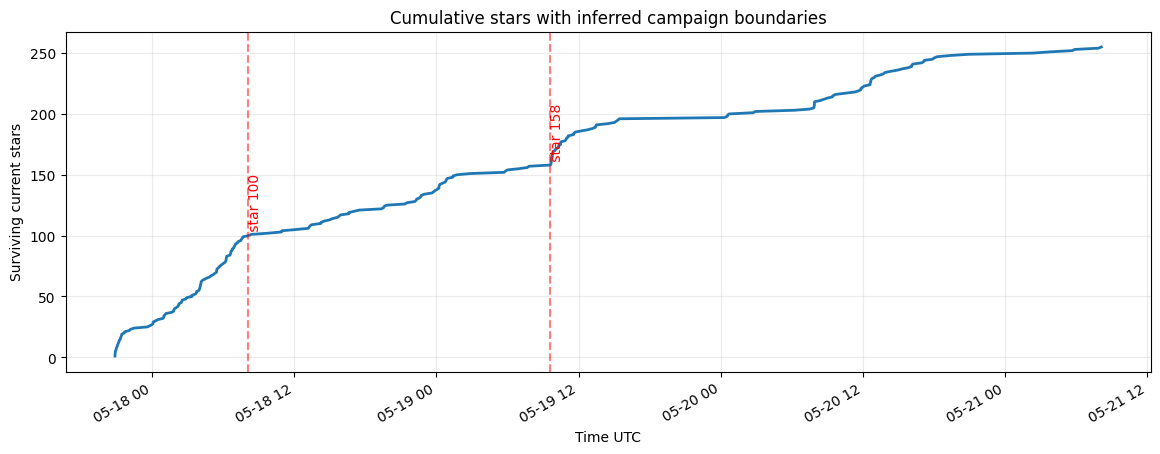

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
stars.plot(x="starred_at", y="star_number", ax=ax, linewidth=2, legend=False)
for boundary in [100, 158]:
    boundary_time = stars.loc[stars["star_number"] == boundary, "starred_at"].iloc[0]
    ax.axvline(boundary_time, color="red", linestyle="--", alpha=0.5)
    ax.text(boundary_time, boundary, f" star {boundary}", rotation=90, va="bottom", color="red")
ax.set_title("Cumulative stars with inferred campaign boundaries")
ax.set_xlabel("Time UTC")
ax.set_ylabel("Surviving current stars")
ax.grid(True, alpha=0.25)
plt.show()

In [10]:
star_profiles.to_csv(output_dir / "slopless-stargazer-analysis.csv", index=False)
bucket_summary.to_csv(output_dir / "slopless-star-bucket-summary.csv")
print(f"wrote {output_dir / 'slopless-stargazer-analysis.csv'} and {output_dir / 'slopless-star-bucket-summary.csv'}")

wrote analytics/star-history/slopless-stargazer-analysis.csv and analytics/star-history/slopless-star-bucket-summary.csv


In [11]:
minute_curve.to_csv(output_dir / "slopless-stars-by-minute.csv")
stars.to_csv(output_dir / "slopless-stars-expanded.csv", index=False)
print(f"wrote {output_dir / 'slopless-stars-by-minute.csv'} and {output_dir / 'slopless-stars-expanded.csv'}")

wrote analytics/star-history/slopless-stars-by-minute.csv and analytics/star-history/slopless-stars-expanded.csv
